In [101]:
import tf_idf_observer as tid
import matplotlib.pyplot as plt
import pandas as pd



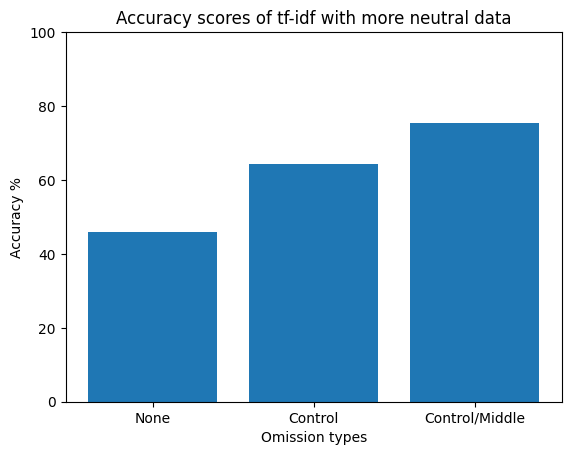

In [102]:
accuracy_all_neutral, confusion_matrix_all_neutral = tid.tf_idf_accuracy('synthetic_conversations_full.csv', False, False)
accuracy_noctrl_neutral, confusion_matrix_noctrl_neutral = tid.tf_idf_accuracy('synthetic_conversations_full.csv', True, False)
accuracy_noctrl_middle_neutral, confusion_matrix_noctrl_middle_neutral = tid.tf_idf_accuracy('synthetic_conversations_full.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_neutral*100, accuracy_noctrl_neutral*100, accuracy_noctrl_middle_neutral*100]
plt.bar(tests, scores)
plt.title("Accuracy scores of tf-idf with more neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

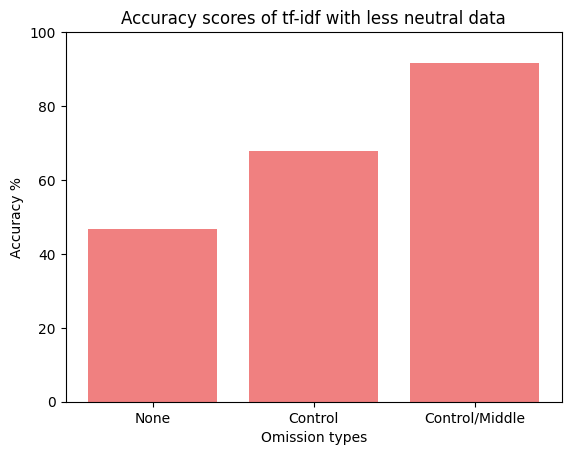

In [103]:
accuracy_all_bias, confusion_matrix_all_bias = tid.tf_idf_accuracy('synthetic_conversations_bias.csv', False, False)
accuracy_noctrl_bias, confusion_matrix_noctrl_bias = tid.tf_idf_accuracy('synthetic_conversations_bias.csv', True, False)
accuracy_noctrl_middle_bias, confusion_matrix_noctrl_middle_bias = tid.tf_idf_accuracy('synthetic_conversations_bias.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_bias*100, accuracy_noctrl_bias*100, accuracy_noctrl_middle_bias*100]
plt.bar(tests, scores, color='lightcoral')
plt.title("Accuracy scores of tf-idf with less neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

In [104]:
llm_data_zshot = pd.read_csv('neutral_data_zero_shot_llm_observer.csv')
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 0]
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 2]

llm_labels_zshot = llm_data_zshot['label'].tolist()
llm_predictions_zshot = llm_data_zshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_zshot)):
    if(llm_labels_zshot[i] == llm_predictions_zshot[i]):
        correct_pred += 1

llm_accuracy_zshot = round(float(correct_pred)/float(len(llm_labels_zshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_zshot, "%")


LLM Accuracy:  44.78 %


In [105]:
llm_data_fshot = pd.read_csv('neutral_data_few_shot_llm_observer.csv')
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 0]
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 2]

llm_labels_fshot = llm_data_fshot['label'].tolist()
llm_predictions_fshot = llm_data_fshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_fshot)):
    if(llm_labels_fshot[i] == llm_predictions_fshot[i]):
        correct_pred += 1

llm_accuracy_fshot = round(float(correct_pred)/float(len(llm_labels_fshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_fshot, "%")


LLM Accuracy:  53.99 %


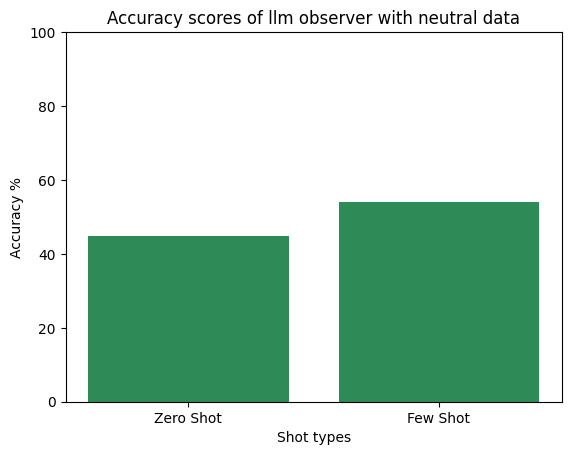

In [106]:
shots = ["Zero Shot", "Few Shot"]
llm_scores = [llm_accuracy_zshot, llm_accuracy_fshot]
plt.bar(shots, llm_scores, color="seagreen")
plt.title("Accuracy scores of llm observer with neutral data")
plt.xlabel("Shot types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()